plot_SHAP_analysis notebook
- Performs global and local feature importance analysis on trained FALCON models, generating summary plots
- Ensure the <u>Python 3.11 kernel (falcon-env)</u> is selected.
- Run configuration before plotting
- Note: This script requires pre-trained models generated from run_FALCON.py.

In [31]:
### Required Run Parameters ### 

RUN_NAME = "Updated_THP1_HepG2_Model" #Name of folder from which to load the model
cell_type_list = ['nLnRLU_THP1','nLnRLU_HEPG2','nLnRLU_Diff'] #List of cell types to be used for evaluation
input_param_order = ['(IL+HL)', 'NP_ratio','HL_(IL+HL)','PEG_(Chol+PEG)']

##### Configuration #####

In [32]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap
import os

In [33]:
# store models in dictionary 
models = {}
input_scalars = {}
output_scalars = {}

for cell_type in cell_type_list:
    model_path = f'../output/{RUN_NAME}/{cell_type}/'
    with open(f'{model_path}Pipeline_dict.pkl', 'rb') as file:
        pipeline = pickle.load(file)
    models[cell_type] = pipeline['Model_Selection']['Best_Model']['Model']
    output_scalars[cell_type] = pipeline['Data_preprocessing']['Output_Scaler']
    input_scalars[cell_type] = pipeline['Data_preprocessing']['Scalers']

train_data = pipeline['Data_preprocessing']['X']
input_param_names = pipeline['Data_preprocessing']['Input_Params']

In [34]:
# Define the output path
output_path = os.path.join("..", "output", RUN_NAME)

# Create the directory if it doesn't exist
if not os.path.exists(output_path):
    print ("No output directory with trained model found!")

SHAP_save_path = os.path.join(output_path, "SHAP_values")

if not os.path.exists(SHAP_save_path):
    print("Creating SHAP values directory at:", SHAP_save_path)
    os.makedirs(SHAP_save_path)
else:
    print("SHAP values directory already exists at:", SHAP_save_path)


SHAP values directory already exists at: ..\output\Updated_THP1_HepG2_Model\SHAP_values


In [35]:
shap_values = {}

for cell_type in cell_type_list:
    explainer = shap.Explainer(models[cell_type])
    X = pd.DataFrame(train_data, columns=input_param_names)
    shap_values[cell_type] = explainer(X)

len(shap_values[cell_type])

96

##### Global Feature Importance Plots #####

Beeswarm plot for nLnRLU_THP1:


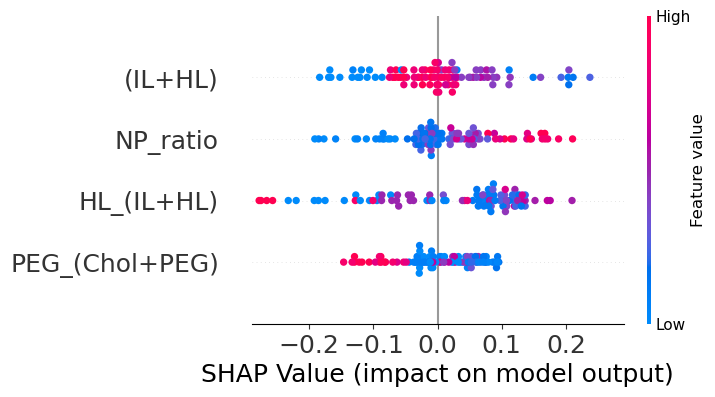

Beeswarm plot for nLnRLU_HEPG2:


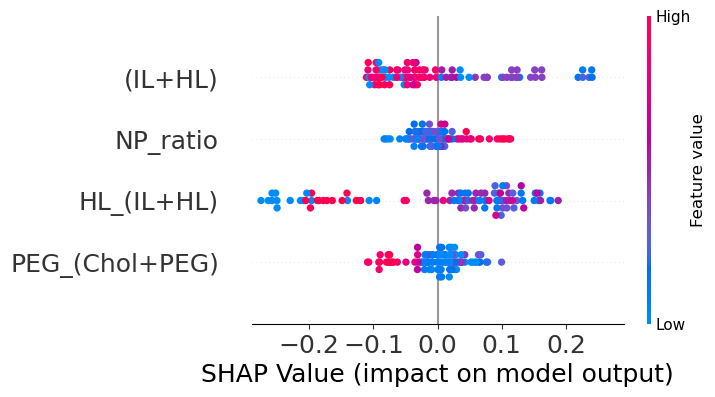

In [13]:
# Beeswarm plots for each cell type

for cell_type in cell_type_list:
    feature_order = [list(shap_values[cell_type].feature_names).index(name) for name in input_param_order]
    fig, ax1 = plt.subplots(1, 1, figsize = (15, 15))
    shap.plots.beeswarm(shap_values[cell_type], order = feature_order, color_bar=True, show=False, s=28)
    ax1.set_xlabel("SHAP Value (impact on model output)", fontsize = 18)
    ax1.set_xlim(-0.29,0.29) 
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_color('black') 
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    #increase x tick
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    plt.gcf().set_size_inches(6,4)
    plt.grid(visible=False)
    save_path = os.path.join(SHAP_save_path, f'_Summary_Beeswarm_{cell_type}.svg'),
    plt.savefig(
        f'_Summary_Beeswarm_{cell_type}.svg',
        bbox_inches='tight', dpi=300, transparent=True
    )
    print(f'Beeswarm plot for {cell_type}:')
    plt.show()
    plt.close() 


Dependence plots for nLnRLU_THP1:


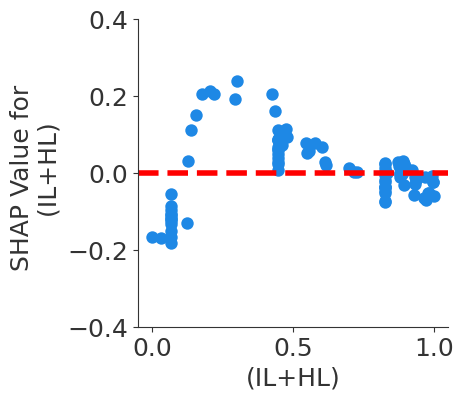

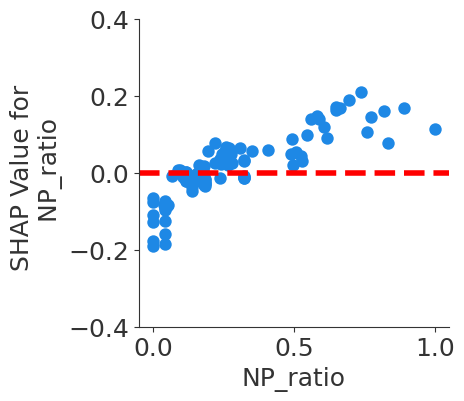

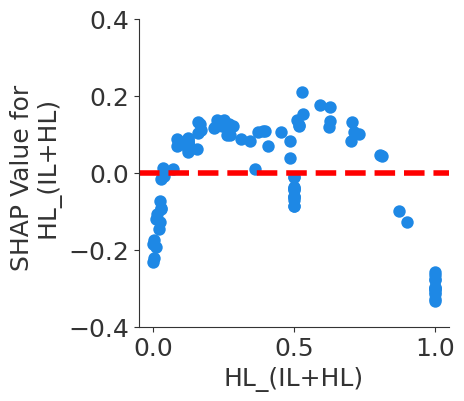

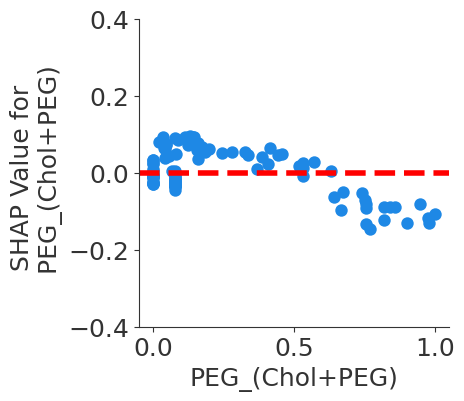

Dependence plots for nLnRLU_HEPG2:


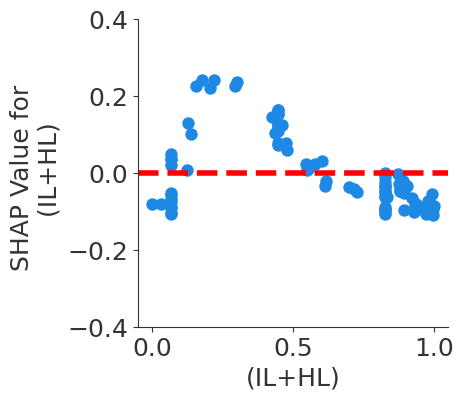

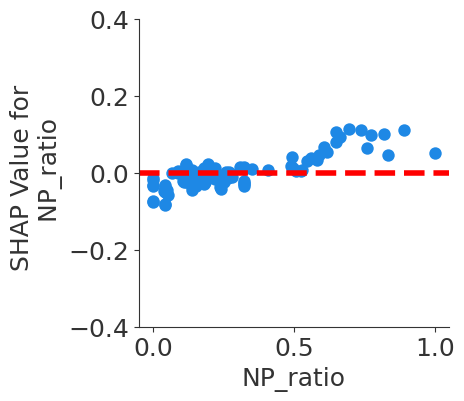

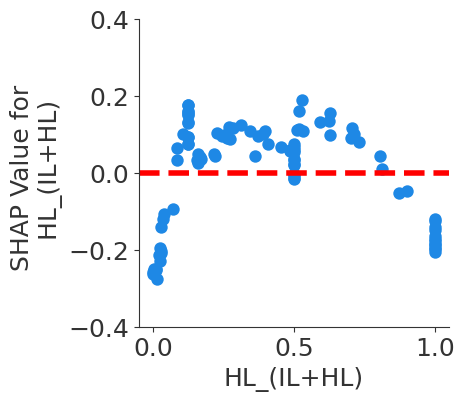

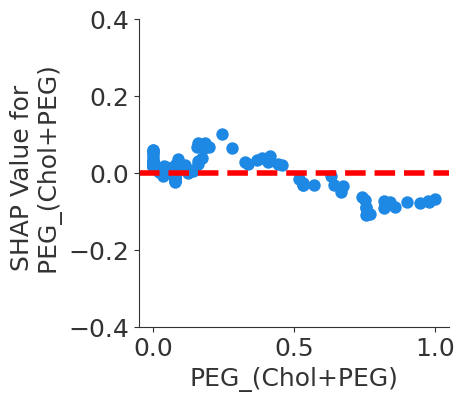

In [16]:
# Dependence plots of each input param for each cell type 

for cell_type in cell_type_list:
    print(f'Dependence plots for {cell_type}:')
    for i, param in enumerate(input_param_order):
        # Create a new figure and axis for each plot
        fig, ax = plt.subplots(figsize=(4, 4))

        # Generate SHAP scatter plot and plot it on the given axis
        shap.plots.scatter(shap_values[cell_type][:, param], dot_size=80, show=False, ax=ax, hist = False)

        # Draw a horizontal line at SHAP value = 0
        ax.axhline(y=0, color='red', linestyle='--', linewidth=4)

        ax.set_ylabel(f"SHAP Value for \n {param}", fontsize=18)
        ax.set_xlabel(param, fontsize=18)

        # Increase tick size
        ax.tick_params(axis='both', labelsize=18)

        # Set consistent y-axis limits
        ax.set_ylim(-0.4, 0.4)

        # Remove grid
        ax.grid(False)

        plt.savefig(
            f'_Dependence_param_{i}_{cell_type}.svg',
            bbox_inches='tight', dpi=300, transparent=True
        )
        plt.show()
        plt.close() 


##### Local Feature Importance Plots #####

In [25]:
# Inverse transform the input parameters for the train data
# scalers should be the same for all cell types, so we can use the first one

train_data_reversed = train_data.copy()
for param in input_param_order:
    #inverse transfrorm the input paramter 
    if param in input_scalars[cell_type_list[0]]:
        train_data_reversed[param] = input_scalars[cell_type_list[0]][param].inverse_transform(train_data_reversed[[param]])

Top FALCON LNP index: 80 

Scaled Formulation Composition:
NP_ratio          0.254791
(IL+HL)           0.970033
HL_(IL+HL)        0.159256
PEG_(Chol+PEG)    0.130724
Name: 79, dtype: float64


Original Formulation Composition:
NP_ratio           8.751696
(IL+HL)           87.610989
HL_(IL+HL)         6.377275
PEG_(Chol+PEG)     5.856404
Name: 79, dtype: float64
SHAP values for nLnRLU_THP1 at index 80:
NP_ratio: 0.0464
(IL+HL): 0.0077
HL_(IL+HL): 0.1205
PEG_(Chol+PEG): 0.0866


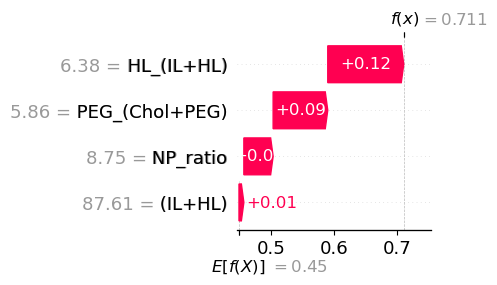

SHAP values for nLnRLU_HEPG2 at index 80:
NP_ratio: -0.0107
(IL+HL): -0.0932
HL_(IL+HL): 0.0261
PEG_(Chol+PEG): 0.0033


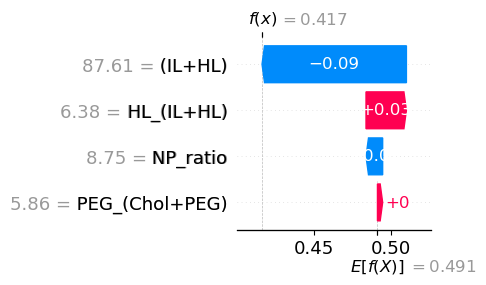

SHAP values for nLnRLU_Diff at index 80:
NP_ratio: 0.0170
(IL+HL): 0.1962
HL_(IL+HL): 0.0611
PEG_(Chol+PEG): 0.1370


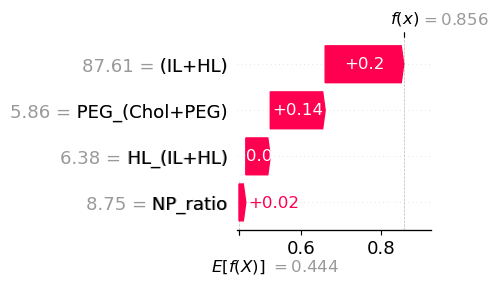

In [36]:
# Top Ramos SO FALCON LNP 
index = 80 
print(f"Top FALCON LNP index: {index} \n")

print('Scaled Formulation Composition:')
print(train_data.iloc[index-1])
 
print('\n') 
print('Original Formulation Composition:')
print(train_data_reversed.iloc[index-1])

rounded_feature_values = np.round(train_data_reversed.iloc[index-1], 2)

for cell_type in cell_type_list:
    shap_values_selected = shap_values[cell_type][index-1]
    shap_values_rounded = shap.Explanation(
        values=shap_values_selected.values,  # Keep original SHAP values
        base_values=shap_values_selected.base_values,  # Keep original base value
        data=rounded_feature_values,  # Use rounded feature values
        feature_names=shap_values_selected.feature_names  # Keep original feature names
    )
    fig, ax1 = plt.subplots(1, 1, figsize = (15, 15))
    print(f'SHAP values for {cell_type} at index {index}:')
    #waterfall plot
    shap.plots.waterfall(shap_values_rounded, show = False)

    #print the shape values out 
    for i, (feature, value) in enumerate(zip(shap_values_rounded.feature_names, shap_values_rounded.values)):
        print(f"{feature}: {value:.4f}")

    ax1.set_xlabel("")
    plt.gcf().set_size_inches(2.5,2.5)
    save_path = os.path.join(SHAP_save_path, f'Waterfall_Formulation_{index}_{cell_type}.svg'),
    plt.savefig(
        "80_Waterfall.svg",
        bbox_inches='tight', dpi=300, transparent=True
    )
    plt.show()
    plt.close()

Top Ramos Dual Obj FALCON LNP index: 225 

Scaled Formulation Composition:
NP_ratio        0.041629
PEG_PEG+Chol    0.278751
IL+HL           0.425308
HL_IL+HL        0.579960
Name: 224, dtype: float64


Original Formulation Composition:
NP_ratio         4.996358
PEG_PEG+Chol     7.631056
IL+HL           52.401231
HL_IL+HL        56.093365
Name: 224, dtype: float64
SHAP values for RAMOS at index 225:


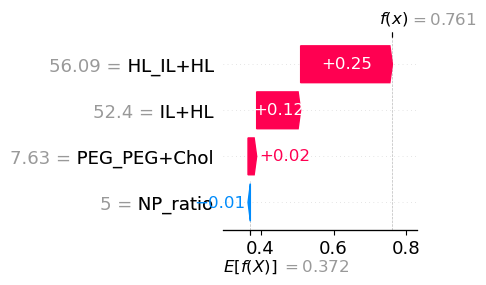

SHAP values for THP1 at index 225:


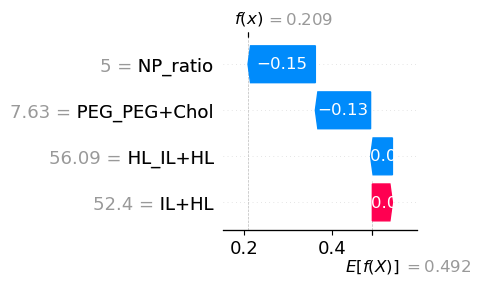

SHAP values for Skewed_Diff at index 225:


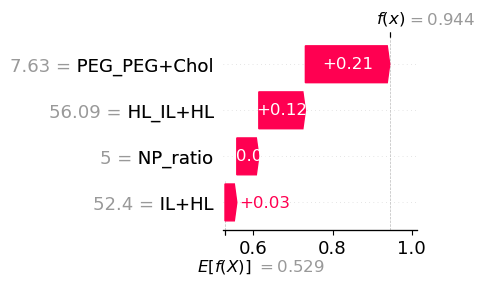

In [33]:
# Top Ramos DO FALCON LNP 
index = 225 
print(f"Top Ramos Dual Obj FALCON LNP index: {index} \n")

print('Scaled Formulation Composition:')
print(train_data.iloc[index-1])
 
print('\n') 
print('Original Formulation Composition:')
print(train_data_reversed.iloc[index-1])

rounded_feature_values = np.round(train_data_reversed.iloc[index-1], 2)

for cell_type in cell_type_list:
    shap_values_selected = shap_values[cell_type][index-1]
    shap_values_rounded = shap.Explanation(
        values=shap_values_selected.values,  # Keep original SHAP values
        base_values=shap_values_selected.base_values,  # Keep original base value
        data=rounded_feature_values,  # Use rounded feature values
        feature_names=shap_values_selected.feature_names  # Keep original feature names
    )
    fig, ax1 = plt.subplots(1, 1, figsize = (15, 15))
    print(f'SHAP values for {cell_type} at index {index}:')
    #waterfall plot
    shap.plots.waterfall(shap_values_rounded, show = False)
    ax1.set_xlabel("")
    plt.gcf().set_size_inches(2.5,2.5)
    save_path = os.path.join(SHAP_save_path, f'Waterfall_Formulation_{index}_{cell_type}.svg'),
    plt.savefig(
        save_path[0],
        bbox_inches='tight', dpi=300, transparent=True
    )
    plt.show()
    plt.close()

Top Ramos Dual Obj FALCON LNP index: 178 

Scaled Formulation Composition:
NP_ratio        0.727481
PEG_PEG+Chol    0.008224
IL+HL           0.603417
HL_IL+HL        0.089855
Name: 177, dtype: float64


Original Formulation Composition:
NP_ratio        21.411649
PEG_PEG+Chol     0.418859
IL+HL           65.970078
HL_IL+HL         9.111128
Name: 177, dtype: float64
SHAP values for RAMOS at index 178:


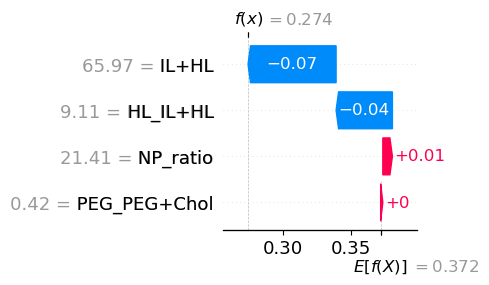

SHAP values for THP1 at index 178:


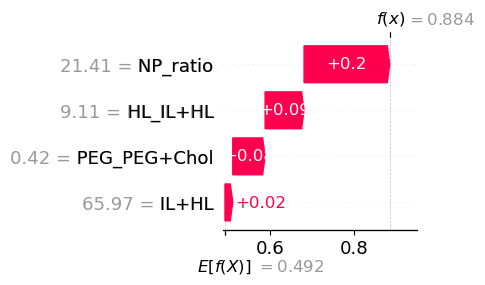

SHAP values for Skewed_Diff at index 178:


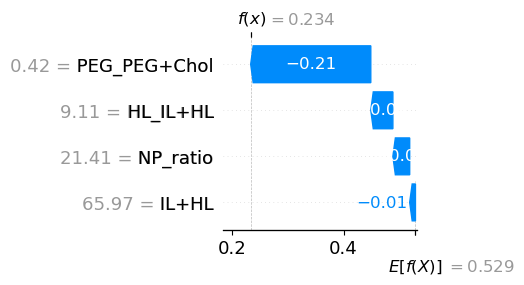

In [34]:
# Top THP1 SO FALCON LNP 
index = 178 
print(f"Top Ramos Dual Obj FALCON LNP index: {index} \n")

print('Scaled Formulation Composition:')
print(train_data.iloc[index-1])
 
print('\n') 
print('Original Formulation Composition:')
print(train_data_reversed.iloc[index-1])

rounded_feature_values = np.round(train_data_reversed.iloc[index-1], 2)

for cell_type in cell_type_list:
    shap_values_selected = shap_values[cell_type][index-1]
    shap_values_rounded = shap.Explanation(
        values=shap_values_selected.values,  # Keep original SHAP values
        base_values=shap_values_selected.base_values,  # Keep original base value
        data=rounded_feature_values,  # Use rounded feature values
        feature_names=shap_values_selected.feature_names  # Keep original feature names
    )
    fig, ax1 = plt.subplots(1, 1, figsize = (15, 15))
    print(f'SHAP values for {cell_type} at index {index}:')
    #waterfall plot
    shap.plots.waterfall(shap_values_rounded, show = False)
    ax1.set_xlabel("")
    plt.gcf().set_size_inches(2.5,2.5)
    save_path = os.path.join(SHAP_save_path, f'Waterfall_Formulation_{index}_{cell_type}.svg'),
    plt.savefig(
        save_path[0],
        bbox_inches='tight', dpi=300, transparent=True
    )
    plt.show()
    plt.close()

Top Ramos Dual Obj FALCON LNP index: 192 

Scaled Formulation Composition:
NP_ratio        0.341951
PEG_PEG+Chol    0.000087
IL+HL           0.729340
HL_IL+HL        0.005294
Name: 191, dtype: float64


Original Formulation Composition:
NP_ratio        12.184318
PEG_PEG+Chol     0.201930
IL+HL           75.563274
HL_IL+HL         1.004978
Name: 191, dtype: float64
SHAP values for RAMOS at index 192:


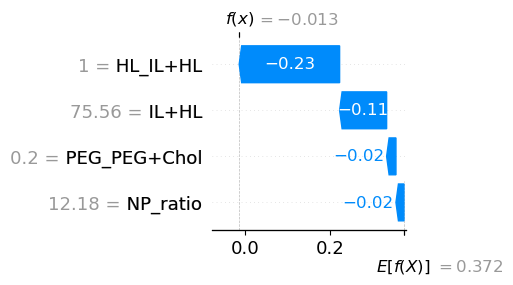

SHAP values for THP1 at index 192:


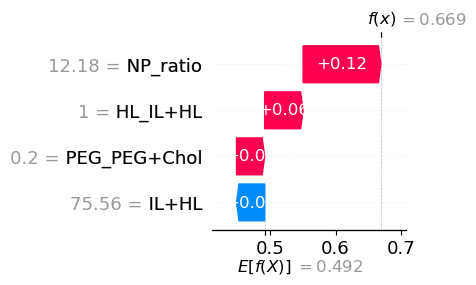

SHAP values for Skewed_Diff at index 192:


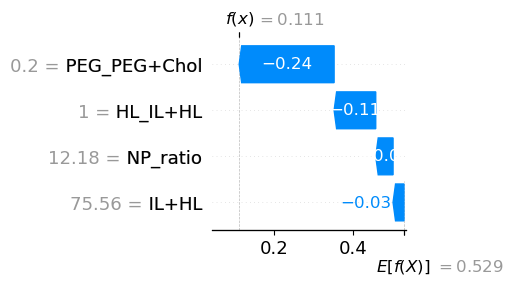

In [35]:
# Top THP1 DO FALCON LNP 
index = 192
print(f"Top Ramos Dual Obj FALCON LNP index: {index} \n")

print('Scaled Formulation Composition:')
print(train_data.iloc[index-1])
 
print('\n') 
print('Original Formulation Composition:')
print(train_data_reversed.iloc[index-1])

rounded_feature_values = np.round(train_data_reversed.iloc[index-1], 2)

for cell_type in cell_type_list:
    shap_values_selected = shap_values[cell_type][index-1]
    shap_values_rounded = shap.Explanation(
        values=shap_values_selected.values,  # Keep original SHAP values
        base_values=shap_values_selected.base_values,  # Keep original base value
        data=rounded_feature_values,  # Use rounded feature values
        feature_names=shap_values_selected.feature_names  # Keep original feature names
    )
    fig, ax1 = plt.subplots(1, 1, figsize = (15, 15))
    print(f'SHAP values for {cell_type} at index {index}:')
    #waterfall plot
    shap.plots.waterfall(shap_values_rounded, show = False)
    ax1.set_xlabel("")
    plt.gcf().set_size_inches(2.5,2.5)
    save_path = os.path.join(SHAP_save_path, f'Waterfall_Formulation_{index}_{cell_type}.svg'),
    plt.savefig(
        save_path[0],
        bbox_inches='tight', dpi=300, transparent=True
    )
    plt.show()
    plt.close()